<a href="https://colab.research.google.com/github/SanikaNShaha/Gujarati-Kachchi-Cyber-Threat-Detection/blob/main/Gujarati_Kachchi_Cyber_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PHASE 1: Gujarati/Kachchi Cyber Threat Detection
# Dataset Creation + TF-IDF + Logistic Regression Baseline
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("✅ Libraries installed and imported successfully")


# ------------------------------------------------------------
# 1. CREATE INITIAL DATASET
# ------------------------------------------------------------

data = [

    # ---------------- PHISHING ----------------
    ("તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો.", "Phishing"),
    ("તમારા બેંક ખાતામાં સમસ્યા છે, આ લિંક પર ક્લિક કરો.", "Phishing"),
    ("તમારું KYC પૂર્ણ કરવા માટે અહીં ક્લિક કરો.", "Phishing"),
    ("તમારા ATM કાર્ડને બ્લોક થવાથી બચાવવા OTP આપો.", "Phishing"),
    ("Bank verification માટે તમારો OTP મોકલો.", "Phishing"),
    ("Click the link immediately to verify your bank account.", "Phishing"),
    ("Your account will be blocked. Verify now.", "Phishing"),

    # ---------------- FINANCIAL SCAM ----------------
    ("તમે લોટરી જીતી છે. ઇનામ મેળવવા પહેલા પૈસા મોકલો.", "Financial_Scam"),
    ("તમારા ખાતામાં 50000 રૂપિયા જમા થયા છે, processing fee ભરો.", "Financial_Scam"),
    ("તમને cashback મળ્યું છે, claim કરવા payment કરો.", "Financial_Scam"),
    ("Congratulations you won a lottery prize. Pay the fee.", "Financial_Scam"),
    ("You have won a cash reward. Send money to receive it.", "Financial_Scam"),

    # ---------------- JOB SCAM ----------------
    ("ઘરે બેઠા દરરોજ 5000 રૂપિયા કમાવાની job.", "Job_Scam"),
    ("તમને online job મળી છે, registration fee ભરો.", "Job_Scam"),
    ("કોઈ interview વગર high salary job માટે સંપર્ક કરો.", "Job_Scam"),
    ("Pay registration fees and get a work from home job.", "Job_Scam"),
    ("Congratulations, you are selected for an online job.", "Job_Scam"),

    # ---------------- ACCOUNT TAKEOVER ----------------
    ("તમારા account નો password તરત બદલો.", "Account_Takeover"),
    ("તમારા social media accountમાં અજાણી login activity છે.", "Account_Takeover"),
    ("Your account has suspicious login activity. Verify immediately.", "Account_Takeover"),
    ("Someone is trying to access your account.", "Account_Takeover"),

    # ---------------- CYBERBULLYING ----------------
    ("તને online જોઈ લઈશ અને બધાને બદનામ કરીશ.", "Cyberbullying"),
    ("તારા ફોટા સોશિયલ મીડિયા પર વાયરલ કરી દઈશ.", "Cyberbullying"),
    ("I will post your private photos online.", "Cyberbullying"),
    ("You are useless and everyone will know about you.", "Cyberbullying"),

    # ---------------- IDENTITY THEFT ----------------
    ("તમારો Aadhaar નંબર અને PAN કાર્ડ મોકલો.", "Identity_Theft"),
    ("તમારી ઓળખ ચકાસવા માટે personal documents મોકલો.", "Identity_Theft"),
    ("Send your Aadhaar and PAN details for verification.", "Identity_Theft"),
    ("Please send your identity documents immediately.", "Identity_Theft"),

    # ---------------- MALWARE ----------------
    ("આ APK download કરો અને reward મેળવો.", "Malware"),
    ("આ software install કરો અને free gift મેળવો.", "Malware"),
    ("Download this unknown APK to claim your prize.", "Malware"),
    ("Install this file to get free rewards.", "Malware"),

    # ---------------- NORMAL ----------------
    ("આજે કોલેજમાં cybersecurity lecture છે.", "Normal"),
    ("કાલે સવારે 10 વાગ્યે meeting છે.", "Normal"),
    ("મને આજે assignment submit કરવાનું છે.", "Normal"),
    ("આજે હવામાન ખૂબ સારું છે.", "Normal"),
    ("Let's meet tomorrow for the project discussion.", "Normal"),
    ("The cybersecurity seminar is scheduled tomorrow.", "Normal"),
    ("I completed my college assignment today.", "Normal"),
]

df = pd.DataFrame(data, columns=["text", "category"])

print("\n📊 Dataset created")
print("Total records:", len(df))


# ------------------------------------------------------------
# 2. TEXT CLEANING
# ------------------------------------------------------------

def clean_text(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Convert URLs into URL token
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)


# ------------------------------------------------------------
# 3. DISPLAY DATASET
# ------------------------------------------------------------

print("\nFirst 10 records:")
display(df.head(10))

print("\nCategory Distribution:")
display(df["category"].value_counts())


# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ------------------------------------------------------------
# 5. TF-IDF FEATURE EXTRACTION
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF feature matrix:")
print("Training:", X_train_tfidf.shape)
print("Testing :", X_test_tfidf.shape)


# ------------------------------------------------------------
# 6. LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)


# ------------------------------------------------------------
# 7. MODEL EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print(" MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


# ------------------------------------------------------------
# 8. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Phase 1 - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. TEST CUSTOM MESSAGES
# ------------------------------------------------------------

test_messages = [
    "તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો.",
    "You won a lottery, click the link to receive money.",
    "તમને ઘરે બેઠા સારી job મળી છે.",
    "આજે કોલેજમાં cybersecurity lecture છે.",
    "તમારો Aadhaar નંબર verification માટે મોકલો."
]

test_clean = [clean_text(x) for x in test_messages]

test_features = tfidf.transform(test_clean)

predictions = model.predict(test_features)
probabilities = model.predict_proba(test_features)

print("\n==============================")
print(" CUSTOM MESSAGE PREDICTIONS")
print("==============================")

for msg, pred, prob in zip(
    test_messages,
    predictions,
    probabilities
):

    confidence = np.max(prob) * 100

    print("\nMessage:", msg)
    print("Prediction:", pred)
    print(f"Confidence: {confidence:.2f}%")


# ------------------------------------------------------------
# 10. SAVE DATASET + MODEL
# ------------------------------------------------------------

df.to_csv(
    "Gujarati_Cyber_Initial_Dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

import joblib

joblib.dump(
    tfidf,
    "Gujarati_Cyber_TFIDF_Vectorizer.pkl"
)

joblib.dump(
    model,
    "Gujarati_Cyber_TFIDF_LogisticRegression.pkl"
)

print("\n✅ Phase 1 completed successfully!")

print("\nSaved files:")
print("1. Gujarati_Cyber_Initial_Dataset.csv")
print("2. Gujarati_Cyber_TFIDF_Vectorizer.pkl")
print("3. Gujarati_Cyber_TFIDF_LogisticRegression.pkl")

In [ ]:
# ============================================================
# PHASE 2: Research-Level Gujarati / Roman Gujarati / Kachchi
# Dataset Structuring + Metadata + Script Detection
# ============================================================

import pandas as pd
import numpy as np
import re
import unicodedata
import os

print("🚀 PHASE 2 STARTED")


# ------------------------------------------------------------
# 1. LOAD PHASE 1 DATASET
# ------------------------------------------------------------

INPUT_FILE = "Gujarati_Cyber_Initial_Dataset.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"{INPUT_FILE} not found. Run Phase 1 first."
    )

df = pd.read_csv(
    INPUT_FILE,
    encoding="utf-8-sig"
)

print("\nOriginal dataset shape:", df.shape)


# ------------------------------------------------------------
# 2. CLEAN TEXT AGAIN
# ------------------------------------------------------------

def clean_text(text):

    text = str(text)

    text = unicodedata.normalize(
        "NFC",
        text
    )

    # Replace URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # Normalize spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)


# ------------------------------------------------------------
# 3. LANGUAGE / SCRIPT DETECTION
# ------------------------------------------------------------

def detect_script(text):

    text = str(text)

    gujarati_chars = re.findall(
        r'[\u0A80-\u0AFF]',
        text
    )

    latin_chars = re.findall(
        r'[A-Za-z]',
        text
    )

    total_letters = len(
        gujarati_chars
    ) + len(
        latin_chars
    )

    if total_letters == 0:
        return "Unknown"

    gujarati_ratio = (
        len(gujarati_chars) /
        total_letters
    )

    latin_ratio = (
        len(latin_chars) /
        total_letters
    )

    if gujarati_ratio >= 0.50:
        return "Gujarati"

    elif latin_ratio >= 0.50:
        return "Roman_Gujarati_or_English"

    else:
        return "Mixed"


df["detected_script"] = df["clean_text"].apply(
    detect_script
)


# ------------------------------------------------------------
# 4. LANGUAGE FIELD
# ------------------------------------------------------------

def assign_language(row):

    script = row["detected_script"]

    if script == "Gujarati":
        return "Gujarati"

    elif script == "Roman_Gujarati_or_English":

        text = row["clean_text"].lower()

        # Gujarati-specific common words
        gujarati_words = [
            "tame",
            "tamaro",
            "tamari",
            "chhe",
            "che",
            "mate",
            "account",
            "bank",
            "otp",
            "moklo",
            "aapo",
            "job",
            "paisaa"
        ]

        score = sum(
            1
            for word in gujarati_words
            if word in text.split()
        )

        if score >= 1:
            return "Roman_Gujarati"

        return "English"

    else:
        return "Mixed"


df["language"] = df.apply(
    assign_language,
    axis=1
)


# ------------------------------------------------------------
# 5. SOURCE TYPE
# ------------------------------------------------------------

# These Phase 1 examples are synthetic seed examples.
df["source_type"] = "Synthetic"

df["source"] = (
    "Research seed dataset"
)


# ------------------------------------------------------------
# 6. RISK LEVEL
# ------------------------------------------------------------

risk_mapping = {

    "Phishing": "High",
    "Financial_Scam": "Critical",
    "Job_Scam": "High",
    "Account_Takeover": "Critical",
    "Cyberbullying": "Medium",
    "Identity_Theft": "Critical",
    "Malware": "Critical",
    "Normal": "Low"
}

df["risk"] = df["category"].map(
    risk_mapping
).fillna("Unknown")


# ------------------------------------------------------------
# 7. TEXT STATISTICS
# ------------------------------------------------------------

df["text_length"] = (
    df["clean_text"]
    .astype(str)
    .str.len()
)


# ------------------------------------------------------------
# 8. URL DETECTION
# ------------------------------------------------------------

def contains_url(text):

    return int(
        bool(
            re.search(
                r'https?://|www\.',
                str(text),
                re.IGNORECASE
            )
        )
    )


df["has_url"] = df["text"].apply(
    contains_url
)


# ------------------------------------------------------------
# 9. EMOJI DETECTION
# ------------------------------------------------------------

def contains_emoji(text):

    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "\U00002700-\U000027BF"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )

    return int(
        bool(
            emoji_pattern.search(
                str(text)
            )
        )
    )


df["has_emoji"] = df["text"].apply(
    contains_emoji
)


# ------------------------------------------------------------
# 10. CYBER INDICATOR DETECTION
# ------------------------------------------------------------

cyber_keywords = [

    "otp",
    "password",
    "account",
    "bank",
    "kyc",
    "verify",
    "verification",
    "click",
    "link",
    "payment",
    "pay",
    "lottery",
    "prize",
    "reward",
    "job",
    "salary",
    "aadhaar",
    "pan",
    "download",
    "apk",
    "install",
    "login"
]


def keyword_count(text):

    text = str(text).lower()

    return sum(
        text.count(keyword)
        for keyword in cyber_keywords
    )


df["cyber_keyword_count"] = (
    df["clean_text"]
    .apply(keyword_count)
)


# ------------------------------------------------------------
# 11. DISPLAY RESEARCH DATASET
# ------------------------------------------------------------

print("\n==============================")
print(" RESEARCH DATASET")
print("==============================")

display(
    df[
        [
            "text",
            "language",
            "detected_script",
            "category",
            "risk",
            "source_type",
            "text_length",
            "has_url",
            "has_emoji",
            "cyber_keyword_count"
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 12. DATASET STATISTICS
# ------------------------------------------------------------

print("\n==============================")
print(" DATASET STATISTICS")
print("==============================")

print(
    "\nLanguage distribution:"
)

display(
    df["language"].value_counts()
)


print(
    "\nCategory distribution:"
)

display(
    df["category"].value_counts()
)


print(
    "\nRisk distribution:"
)

display(
    df["risk"].value_counts()
)


print(
    "\nSource distribution:"
)

display(
    df["source_type"].value_counts()
)


print(
    "\nDetected script distribution:"
)

display(
    df["detected_script"].value_counts()
)


# ------------------------------------------------------------
# 13. DATA QUALITY CHECK
# ------------------------------------------------------------

print("\n==============================")
print(" DATA QUALITY CHECK")
print("==============================")

print(
    "Missing values:"
)

display(
    df.isnull().sum()
)


print(
    "\nDuplicate rows:",
    df.duplicated().sum()
)


# ------------------------------------------------------------
# 14. SAVE RESEARCH DATASET
# ------------------------------------------------------------

OUTPUT_FILE = (
    "Gujarati_Kachchi_Cyber_Research_Dataset.csv"
)

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 15. SAVE DATASET SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Metric": [
        "Total Records",
        "Unique Categories",
        "Unique Languages",
        "Synthetic Records",
        "Gujarati Records",
        "Roman Gujarati Records",
        "English Records",
        "Rows With URLs"
    ],

    "Value": [

        len(df),

        df["category"].nunique(),

        df["language"].nunique(),

        (df["source_type"] == "Synthetic").sum(),

        (df["language"] == "Gujarati").sum(),

        (df["language"] == "Roman_Gujarati").sum(),

        (df["language"] == "English").sum(),

        df["has_url"].sum()
    ]
})


display(summary)


summary.to_csv(
    "Phase_2_Dataset_Summary.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\n======================================")
print("✅ PHASE 2 COMPLETED SUCCESSFULLY")
print("======================================")

print("\nFiles created:")

print("1. Gujarati_Kachchi_Cyber_Research_Dataset.csv")
print("2. Phase_2_Dataset_Summary.csv")

print(
    "\n⚠️ Research note:"
)

print(
    "Current records are synthetic seed data. "
    "They must not be presented as authentic Kachchi "
    "or real-world cyber data in the research paper."
)

In [ ]:
# ============================================================
# PHASE 3: NLP PREPROCESSING & FEATURE ENGINEERING
# Gujarati–Kachchi NLP-Based Cyber Scam Detection System
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================================
# 1. LOAD DATASET
# ============================================================

# If synthetic_df already exists from Phase 2, use it.
# Otherwise load the CSV file.

try:
    df = synthetic_df.copy()
    print("Using dataset created in previous phase.")
except:
    df = pd.read_csv("Gujarati_Cyber_Synthetic_Corpus.csv")
    print("Dataset loaded from CSV.")

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())

# ============================================================
# 2. BASIC DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Remove missing text
df = df.dropna(subset=["text"]).reset_index(drop=True)

print("\nDataset after removing duplicates/missing values:")
print(df.shape)

# ============================================================
# 3. UNICODE NORMALIZATION
# ============================================================

def normalize_unicode(text):
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    return text

df["text_normalized"] = df["text"].apply(normalize_unicode)

# ============================================================
# 4. URL NORMALIZATION
# ============================================================

def replace_urls(text):
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )
    return text

df["text_no_url"] = df["text_normalized"].apply(replace_urls)

# ============================================================
# 5. BASIC TEXT CLEANING
# ============================================================

def clean_text(text):

    text = str(text)

    # Convert English characters to lowercase
    text = text.lower()

    # Replace URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # Keep Gujarati, English, numbers and basic punctuation
    text = re.sub(
        r'[^\w\s!?.,₹$@:/-]',
        ' ',
        text,
        flags=re.UNICODE
    )

    # Remove extra spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

df["clean_text"] = df["text_normalized"].apply(clean_text)

# ============================================================
# 6. TEXT LENGTH FEATURES
# ============================================================

df["text_length"] = df["clean_text"].apply(len)

df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

# ============================================================
# 7. URL DETECTION
# ============================================================

def contains_url(text):

    pattern = r'https?://\S+|www\.\S+'

    return int(bool(re.search(pattern, str(text))))

df["contains_url"] = df["text"].apply(contains_url)

# ============================================================
# 8. URGENCY WORD DETECTION
# ============================================================

urgency_words = [
    "urgent",
    "immediately",
    "now",
    "today",
    "verify",
    "verify now",
    "તાત્કાલિક",
    "તરત",
    "હમણાં",
    "જલ્દી",
    "તુરંત",
    "વેરિફાય",
    "બંધ",
    "બંધ થઈ જશે"
]

def count_urgency_words(text):

    text = str(text).lower()

    count = 0

    for word in urgency_words:

        if word.lower() in text:
            count += 1

    return count

df["urgency_count"] = df["clean_text"].apply(
    count_urgency_words
)

# ============================================================
# 9. CYBER KEYWORD DETECTION
# ============================================================

cyber_keywords = [

    # Authentication
    "otp",
    "password",
    "પાસવર્ડ",
    "ઓટીપી",
    "verification",
    "verify",

    # Banking
    "bank",
    "બેંક",
    "account",
    "એકાઉન્ટ",
    "upi",
    "payment",
    "પેમેન્ટ",

    # Financial scam
    "money",
    "પૈસા",
    "loan",
    "લોન",
    "lottery",
    "લોટરી",
    "prize",
    "ઇનામ",

    # Cybersecurity
    "virus",
    "malware",
    "hack",
    "hacker",
    "હેક",
    "હેકર",
    "security",
    "સિક્યોરિટી",

    # Social media
    "instagram",
    "facebook",
    "whatsapp",
    "telegram",

    # Job scam
    "job",
    "નૌકરી",
    "જોબ",
    "registration",
    "રજીસ્ટ્રેશન",

    # Link
    "link",
    "લિંક",
    "click",
    "ક્લિક"
]

def count_cyber_keywords(text):

    text = str(text).lower()

    count = 0

    for keyword in cyber_keywords:

        if keyword.lower() in text:
            count += 1

    return count

df["cyber_keyword_count"] = df["clean_text"].apply(
    count_cyber_keywords
)

# ============================================================
# 10. OTP DETECTION
# ============================================================

def contains_otp(text):

    text = str(text).lower()

    otp_terms = [
        "otp",
        "ઓટીપી",
        "one time password"
    ]

    return int(
        any(term in text for term in otp_terms)
    )

df["contains_otp"] = df["clean_text"].apply(
    contains_otp
)

# ============================================================
# 11. MONEY / PAYMENT DETECTION
# ============================================================

def contains_money_terms(text):

    text = str(text).lower()

    money_terms = [
        "₹",
        "rs",
        "rupees",
        "money",
        "પૈસા",
        "રૂપિયા",
        "payment",
        "પેમેન્ટ",
        "upi",
        "બેંક"
    ]

    return int(
        any(term in text for term in money_terms)
    )

df["contains_money"] = df["clean_text"].apply(
    contains_money_terms
)

# ============================================================
# 12. EXCLAMATION / PRESSURE DETECTION
# ============================================================

df["exclamation_count"] = df["clean_text"].apply(
    lambda x: str(x).count("!")
)

# ============================================================
# 13. DISPLAY ENGINEERED FEATURES
# ============================================================

feature_columns = [
    "text",
    "language",
    "category",
    "risk",
    "source_type",
    "clean_text",
    "text_length",
    "word_count",
    "contains_url",
    "urgency_count",
    "cyber_keyword_count",
    "contains_otp",
    "contains_money",
    "exclamation_count"
]

# Display only columns that actually exist
feature_columns = [
    col for col in feature_columns
    if col in df.columns
]

print("\n================ ENGINEERED FEATURES ================\n")

display(
    df[feature_columns].head(10)
)

# ============================================================
# 14. FEATURE STATISTICS
# ============================================================

numeric_features = [
    "text_length",
    "word_count",
    "contains_url",
    "urgency_count",
    "cyber_keyword_count",
    "contains_otp",
    "contains_money",
    "exclamation_count"
]

print("\n================ FEATURE STATISTICS ================\n")

display(
    df[numeric_features].describe()
)

# ============================================================
# 15. CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.title("Cyber Message Category Distribution")
plt.xlabel("Cyber Category")
plt.ylabel("Number of Messages")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 16. URL / OTP / MONEY FEATURE DISTRIBUTION
# ============================================================

feature_counts = pd.DataFrame({
    "Feature": [
        "Contains URL",
        "Contains OTP",
        "Contains Money Terms"
    ],
    "Count": [
        df["contains_url"].sum(),
        df["contains_otp"].sum(),
        df["contains_money"].sum()
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_counts,
    x="Feature",
    y="Count"
)

plt.title("Cybersecurity Feature Distribution")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# ============================================================
# 17. TF-IDF FEATURE EXTRACTION
# ============================================================

X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# Character-level TF-IDF
# Useful for Gujarati + English + Roman Gujarati text

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("\n================ TF-IDF INFORMATION ================\n")

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

print(
    "Number of extracted features:",
    len(tfidf.get_feature_names_out())
)

# ============================================================
# 18. SHOW SAMPLE TF-IDF FEATURES
# ============================================================

print("\nSample TF-IDF features:")

print(
    tfidf.get_feature_names_out()[:50]
)

# ============================================================
# 19. SAVE PREPROCESSED DATA
# ============================================================

df.to_csv(
    "Gujarati_Cyber_Preprocessed_Dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 20. SAVE TF-IDF OBJECT
# ============================================================

import joblib

joblib.dump(
    tfidf,
    "Gujarati_Cyber_TFIDF_Phase3.pkl"
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n======================================================")
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("======================================================")

print("\nGenerated files:")

print("1. Gujarati_Cyber_Preprocessed_Dataset.csv")
print("2. Gujarati_Cyber_TFIDF_Phase3.pkl")

print("\nMain NLP Features Created:")
print("✓ Unicode normalization")
print("✓ URL normalization")
print("✓ Text cleaning")
print("✓ Text length")
print("✓ Word count")
print("✓ URL detection")
print("✓ Urgency detection")
print("✓ Cyber keyword detection")
print("✓ OTP detection")
print("✓ Money/payment detection")
print("✓ TF-IDF character n-grams")

print("\nNEXT → PHASE 4: Train Baseline Cyber Classification Model")

In [ ]:
# ============================================================
# GUJARATI / ROMAN GUJARATI CYBER NLP - COMPLETE BASELINE
# ============================================================

# -----------------------------
# 1. INSTALL / IMPORT
# -----------------------------

!pip -q install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import random
import re
import unicodedata
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

random.seed(42)
np.random.seed(42)

print("Libraries loaded successfully.")


# -----------------------------
# 2. CYBER MESSAGE TEMPLATES
# -----------------------------

templates = {

    "Phishing": [
        "તમારું KYC બંધ થવાનું છે, તરત {action}",
        "તમારું bank account verify કરવા માટે {action}",
        "તમારા account ની verification બાકી છે, {action}",
        "તમારું KYC update કરો નહીં તો account બંધ થઈ જશે",
        "તમારા bank account માટે verification જરૂરી છે, {action}",
        "તમારું account સુરક્ષિત રાખવા માટે {action}",
        "તમારી KYC verification પૂર્ણ કરવા માટે {action}"
    ],

    "Financial_Scam": [
        "તમારા account માં પૈસા આવ્યા છે, OTP {action}",
        "તમને lottery માં ઇનામ મળ્યું છે, પહેલા {action}",
        "તમને {amount} રૂપિયા મળ્યા છે, payment મેળવવા માટે {action}",
        "તમારા UPI payment માટે OTP {action}",
        "પૈસા double કરવા માટે પહેલા {action}",
        "તમારા account માં {amount} રૂપિયા transfer થયા છે, {action}",
        "cashback મેળવવા માટે {action}"
    ],

    "Job_Scam": [
        "ઘરે બેઠા દરરોજ {amount} રૂપિયા કમાવો, પહેલા {action}",
        "તમારી job માટે selection થયું છે, પહેલા {action}",
        "Work from home job માટે registration {action}",
        "તમને online job મળી છે, security deposit {action}",
        "દરરોજ વધારે કમાણી માટે પહેલા {action}",
        "ઘરે બેઠા job મેળવવા માટે {action}",
        "તમારી job confirm કરવા માટે {action}"
    ],

    "Account_Takeover": [
        "તમારા account માં suspicious login થયું છે, {action}",
        "તમારું social media account verify કરો, {action}",
        "તમારા account ની security માટે password {action}",
        "તમારા login ની verification માટે OTP {action}",
        "તમच्या account मध्ये unauthorized login detected, {action}",
        "account secure કરવા માટે verification {action}"
    ],

    "Cyberbullying": [
        "હું તારા વિશે ખરાબ વાતો બધા group માં મોકલીશ",
        "તું online આવ્યો તો તને જોઈ લઈશ",
        "હું તારી personal information બધાને મોકલીશ",
        "તને online બધા સામે અપમાનિત કરીશ",
        "હું તારા વિશે ખોટી માહિતી online મૂકીશ",
        "હું તારી private વાતો બધા લોકોને કહીશ"
    ],

    "Identity_Theft": [
        "તમારી personal information verification માટે {action}",
        "તમારો ID proof અને details {action}",
        "account verification માટે તમારો document {action}",
        "તમારા identity document ની copy {action}",
        "તમારી personal details submit કરવા માટે {action}"
    ],

    "Malware": [
        "આ file download કરો અને application install કરો",
        "આ attachment ખોલીને software install કરો",
        "આ unknown application તમારા phone માં install કરો",
        "આ file download કરીને run કરો",
        "આ application install કરીને account verify કરો"
    ],

    "Normal": [
        "આજે આપણે બજારમાં જઈશું",
        "કાલે કોલેજમાં practical છે",
        "મને આજે ઘરે જમવાનું છે",
        "આજે સાંજે આપણે મળીએ",
        "કાલે તું મને મળવા આવજે",
        "Aaje ame bazar jaisu",
        "Kal college ma practical che",
        "Aaje ghare jamvanu che",
        "Aaje tame kya jasho",
        "Mare kale college javanu che",
        "Aaje ghar ma badha sathe jamvanu che",
        "Kal apde sathe farva jaisu"
    ]
}


# -----------------------------
# 3. VARIABLES
# -----------------------------

actions = [
    "આ link પર click કરો",
    "આ link ખોલો",
    "verification કરો",
    "OTP આપો",
    "details મોકલો",
    "payment કરો",
    "registration કરો",
    "document upload કરો",
    "આ form ભરો"
]

amounts = [
    "5000",
    "10000",
    "25000",
    "50000",
    "100000"
]


# -----------------------------
# 4. GENERATE DATASET
# -----------------------------

generated_data = []

for category, category_templates in templates.items():

    for i in range(150):

        template = random.choice(category_templates)

        text = template.format(
            action=random.choice(actions),
            amount=random.choice(amounts)
        )

        # Detect Gujarati Unicode script
        if any('\u0A80' <= ch <= '\u0AFF' for ch in text):
            language = "Gujarati"
        else:
            language = "Roman_Gujarati"

        # Risk label
        if category == "Normal":
            risk = "Low"

        elif category in [
            "Phishing",
            "Financial_Scam",
            "Job_Scam",
            "Account_Takeover",
            "Identity_Theft",
            "Malware"
        ]:
            risk = "High"

        else:
            risk = "Medium"

        generated_data.append({
            "text": text,
            "language": language,
            "category": category,
            "risk": risk,
            "source_type": "Synthetic"
        })


synthetic_df = pd.DataFrame(generated_data)


# -----------------------------
# 5. REMOVE DUPLICATES
# -----------------------------

before = len(synthetic_df)

synthetic_df = synthetic_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

after = len(synthetic_df)


# -----------------------------
# 6. NORMALIZE TEXT
# -----------------------------

def clean_text(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Replace URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # Normalize spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()


synthetic_df["clean_text"] = synthetic_df[
    "text"
].apply(clean_text)


# -----------------------------
# 7. DISPLAY DATASET INFORMATION
# -----------------------------

print("=" * 60)
print("GUJARATI CYBER NLP DATASET")
print("=" * 60)

print("\nTotal records:", len(synthetic_df))

print("\nCategory distribution:")
print(synthetic_df["category"].value_counts())

print("\nLanguage distribution:")
print(synthetic_df["language"].value_counts())

print("\nRisk distribution:")
print(synthetic_df["risk"].value_counts())

print("\nDuplicates removed:", before - after)


# -----------------------------
# 8. CATEGORY GRAPH
# -----------------------------

plt.figure(figsize=(10, 5))

synthetic_df["category"].value_counts().plot(
    kind="bar"
)

plt.title("Gujarati Cyber NLP Dataset Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------------
# 9. TRAIN / TEST SPLIT
# -----------------------------

X = synthetic_df["clean_text"]
y = synthetic_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------
# 10. TF-IDF
# -----------------------------

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)


# -----------------------------
# 11. LOGISTIC REGRESSION
# -----------------------------

model = LogisticRegression(
    max_iter=3000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("\nModel training completed.")


# -----------------------------
# 12. PREDICTION
# -----------------------------

y_pred = model.predict(
    X_test_tfidf
)


# -----------------------------
# 13. ACCURACY
# -----------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(
    "\nAccuracy:",
    round(accuracy * 100, 2),
    "%"
)


# -----------------------------
# 14. CLASSIFICATION REPORT
# -----------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# -----------------------------
# 15. CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title(
    "Gujarati Cyber NLP - Confusion Matrix"
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# -----------------------------
# 16. SAVE MODEL
# -----------------------------

joblib.dump(
    tfidf,
    "gujarati_cyber_tfidf.pkl"
)

joblib.dump(
    model,
    "gujarati_cyber_classifier.pkl"
)

synthetic_df.to_csv(
    "Gujarati_Cyber_Synthetic_Corpus.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFiles saved:")
print("1. gujarati_cyber_tfidf.pkl")
print("2. gujarati_cyber_classifier.pkl")
print("3. Gujarati_Cyber_Synthetic_Corpus.csv")


# -----------------------------
# 17. TEST YOUR OWN MESSAGE
# -----------------------------

print("\n" + "=" * 60)
print("CUSTOM MESSAGE TEST")
print("=" * 60)

user_message = input(
    "\nEnter Gujarati / Roman Gujarati message: "
)

clean_message = clean_text(
    user_message
)

message_vector = tfidf.transform(
    [clean_message]
)

prediction = model.predict(
    message_vector
)

probabilities = model.predict_proba(
    message_vector
)

confidence = probabilities.max()

print("\n---------- RESULT ----------")

print(
    "Message:",
    user_message
)

print(
    "Predicted Category:",
    prediction[0]
)

print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

print("----------------------------")


# -----------------------------
# 18. TEST EXAMPLES
# -----------------------------

test_messages = [
    "તમારું KYC બંધ થઈ જશે તરત link પર click કરો",
    "તમારા account માં પૈસા આવ્યા છે OTP આપો",
    "ઘરે બેઠા 50000 રૂપિયા કમાવો પહેલા registration કરો",
    "આજે આપણે બજારમાં જઈશું",
    "Tamaru account verify karo OTP aapo",
    "Aaje ame bazar jaisu"
]

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for message in test_messages:

    vector = tfidf.transform([message])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)

    confidence = probability.max()

    print("\nMessage:", message)
    print("Category:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")


print("\n" + "=" * 60)
print("BASELINE PIPELINE COMPLETED")
print("=" * 60)

In [ ]:
# ============================================================
# PHASE 5: MODEL COMPARISON
# Gujarati–Kachchi NLP-Based Cyber Scam Detection
# Logistic Regression vs Linear SVM
# ============================================================

!pip -q install scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

try:
    df = synthetic_df.copy()
    print("Using dataset already present in Colab.")
except:
    df = pd.read_csv("Gujarati_Cyber_Synthetic_Corpus.csv")
    print("Dataset loaded from CSV.")

print("\nDataset Shape:", df.shape)
print("\nCategories:")
print(df["category"].value_counts())

# ------------------------------------------------------------
# 2. TEXT CLEANING
# ------------------------------------------------------------

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    return text

df["clean_text"] = df["text"].apply(clean_text)

# Remove empty rows
df = df[df["clean_text"].str.len() > 2].copy()

# ------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

# ------------------------------------------------------------
# 4. TF-IDF FEATURE EXTRACTION
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape :", X_test_tfidf.shape)

# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred, average="weighted", zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred, average="weighted", zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred, average="weighted", zero_division=0
)

# ============================================================
# MODEL 2: LINEAR SVM
# ============================================================

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(
    y_test, svm_pred, average="weighted", zero_division=0
)
svm_recall = recall_score(
    y_test, svm_pred, average="weighted", zero_division=0
)
svm_f1 = f1_score(
    y_test, svm_pred, average="weighted", zero_division=0
)

# ============================================================
# 5. MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall
    ],
    "F1 Score": [
        lr_f1,
        svm_f1
    ]
})

print("\n================ MODEL COMPARISON ================\n")

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

# ============================================================
# 6. LOGISTIC REGRESSION REPORT
# ============================================================

print("\n================ LOGISTIC REGRESSION ================\n")

print(
    classification_report(
        y_test,
        lr_pred,
        zero_division=0
    )
)

# ============================================================
# 7. SVM REPORT
# ============================================================

print("\n================ LINEAR SVM ================\n")

print(
    classification_report(
        y_test,
        svm_pred,
        zero_division=0
    )
)

# ============================================================
# 8. SVM CONFUSION MATRIX
# ============================================================

labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=labels
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 9. MODEL PERFORMANCE GRAPH
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    comparison.iloc[0][metrics].values.astype(float),
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    comparison.iloc[1][metrics].values.astype(float),
    width,
    label="Linear SVM"
)

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# ============================================================
# 10. CUSTOM CYBER MESSAGE TESTING
# ============================================================

test_messages = [
    "તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત જ આ લિંક પર ક્લિક કરો",
    "Congratulations you won a lottery. Send your OTP to receive money",
    "તમારા Instagram account માટે password verify કરો",
    "તમારી નોકરી માટે registration fee આજે જ ભરો",
    "આજે કોલેજમાં cybersecurity workshop છે"
]

test_clean = [clean_text(x) for x in test_messages]

test_features = tfidf.transform(test_clean)

lr_results = lr_model.predict(test_features)
svm_results = svm_model.predict(test_features)

print("\n================ CUSTOM MESSAGE TEST ================\n")

for i, msg in enumerate(test_messages):

    print("Message:", msg)
    print("Logistic Regression:", lr_results[i])
    print("Linear SVM:", svm_results[i])
    print("-" * 70)

# ============================================================
# 11. SAVE MODELS
# ============================================================

joblib.dump(
    tfidf,
    "Gujarati_Cyber_TFIDF.pkl"
)

joblib.dump(
    lr_model,
    "Gujarati_Cyber_LogisticRegression.pkl"
)

joblib.dump(
    svm_model,
    "Gujarati_Cyber_LinearSVM.pkl"
)

comparison.to_csv(
    "Gujarati_Cyber_Model_Comparison.csv",
    index=False
)

print("\n======================================================")
print("PHASE 5 COMPLETED SUCCESSFULLY")
print("======================================================")

print("\nSaved Files:")
print("1. Gujarati_Cyber_TFIDF.pkl")
print("2. Gujarati_Cyber_LogisticRegression.pkl")
print("3. Gujarati_Cyber_LinearSVM.pkl")
print("4. Gujarati_Cyber_Model_Comparison.csv")

print("\nNext Phase:")
print("Word2Vec / Embedding-based NLP model")

In [ ]:
# ============================================================
# PHASE 6: WORD2VEC + EMBEDDING-BASED CLASSIFICATION
# Gujarati–Kachchi NLP-Based Cyber Scam Detection System
# ============================================================

!pip -q install gensim scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import unicodedata

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

try:
    data = df.copy()
    print("Using dataset already available in Colab.")

except:
    data = pd.read_csv(
        "Gujarati_Cyber_Preprocessed_Dataset.csv"
    )
    print("Dataset loaded from CSV.")

print("\nDataset Shape:", data.shape)

print("\nCategories:")
print(data["category"].value_counts())

# ============================================================
# 2. TEXT CLEANING
# ============================================================

def clean_for_word2vec(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize(
        "NFC",
        text
    )

    # Lowercase English words
    text = text.lower()

    # Replace URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # Keep Unicode characters and numbers
    text = re.sub(
        r'[^\w\s]',
        ' ',
        text,
        flags=re.UNICODE
    )

    # Remove extra spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


data["w2v_text"] = data["text"].apply(
    clean_for_word2vec
)

# ============================================================
# 3. TOKENIZATION
# ============================================================

tokenized_sentences = [
    sentence.split()
    for sentence in data["w2v_text"]
]

print("\nExample tokenized sentence:")
print(tokenized_sentences[0])

# ============================================================
# 4. TRAIN WORD2VEC
# ============================================================

print("\nTraining Word2Vec model...")

word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=50,
    seed=42
)

print("Word2Vec training completed.")

print("\nVocabulary size:")
print(len(word2vec_model.wv))

# ============================================================
# 5. DISPLAY SAMPLE WORD VECTORS
# ============================================================

vocab_words = list(
    word2vec_model.wv.index_to_key
)

print("\nSample vocabulary:")
print(vocab_words[:30])

if len(vocab_words) > 0:

    sample_word = vocab_words[0]

    print("\nExample word:")
    print(sample_word)

    print("\nEmbedding vector:")
    print(
        word2vec_model.wv[sample_word][:10]
    )

# ============================================================
# 6. CONVERT SENTENCE INTO EMBEDDING
# ============================================================

def sentence_vector(
    sentence,
    model,
    vector_size=100
):

    words = sentence.split()

    vectors = []

    for word in words:

        if word in model.wv:

            vectors.append(
                model.wv[word]
            )

    if len(vectors) == 0:

        return np.zeros(
            vector_size
        )

    return np.mean(
        vectors,
        axis=0
    )


sentence_vectors = np.array([
    sentence_vector(
        sentence,
        word2vec_model
    )
    for sentence in data["w2v_text"]
])

print("\nSentence embedding shape:")
print(sentence_vectors.shape)

# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X = sentence_vectors

y = data["category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# ============================================================
# 8. LOGISTIC REGRESSION ON WORD2VEC
# ============================================================

w2v_classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

w2v_classifier.fit(
    X_train,
    y_train
)

print("\nWord2Vec + Logistic Regression trained.")

# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = w2v_classifier.predict(
    X_test
)

# ============================================================
# 10. PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n======================================================")
print("WORD2VEC MODEL PERFORMANCE")
print("======================================================")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\n======================================================")
print("CLASSIFICATION REPORT")
print("======================================================\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Word2Vec + Logistic Regression\nConfusion Matrix"
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# ============================================================
# 13. CUSTOM MESSAGE TEST
# ============================================================

test_messages = [

    "તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત જ લિંક પર ક્લિક કરો",

    "તમારો OTP આપો અને પૈસા મેળવો",

    "Congratulations you won a lottery send your bank details",

    "તમારી નોકરી માટે registration fee ભરો",

    "તમારા Instagram account માટે password verify કરો",

    "તમારા ફોનમાં virus છે application install કરો",

    "આજે કોલેજમાં cybersecurity workshop છે"
]

test_clean = [
    clean_for_word2vec(message)
    for message in test_messages
]

test_vectors = np.array([
    sentence_vector(
        sentence,
        word2vec_model
    )
    for sentence in test_clean
])

test_predictions = w2v_classifier.predict(
    test_vectors
)

test_probabilities = w2v_classifier.predict_proba(
    test_vectors
)

print("\n======================================================")
print("WORD2VEC CUSTOM MESSAGE TEST")
print("======================================================\n")

for i in range(len(test_messages)):

    category = test_predictions[i]

    confidence = (
        np.max(
            test_probabilities[i]
        ) * 100
    )

    print("Message:")
    print(test_messages[i])

    print("\nPredicted Category:")
    print(category)

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print("-" * 75)

# ============================================================
# 14. COMPARE PHASE 4 / 5 TF-IDF WITH WORD2VEC
# ============================================================

comparison_data = {

    "Model": [
        "Word2Vec + Logistic Regression"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1 Score": [
        f1
    ]
}

w2v_comparison = pd.DataFrame(
    comparison_data
)

print("\n======================================================")
print("WORD2VEC MODEL RESULTS")
print("======================================================\n")

display(
    w2v_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

# ============================================================
# 15. SAVE WORD2VEC MODEL
# ============================================================

word2vec_model.save(
    "Gujarati_Cyber_Word2Vec.model"
)

joblib.dump(
    w2v_classifier,
    "Gujarati_Cyber_Word2Vec_Classifier.pkl"
)

w2v_comparison.to_csv(
    "Gujarati_Cyber_Word2Vec_Results.csv",
    index=False
)

# ============================================================
# 16. SAVE EMBEDDINGS
# ============================================================

np.save(
    "Gujarati_Cyber_Sentence_Embeddings.npy",
    sentence_vectors
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n======================================================")
print("PHASE 6 COMPLETED SUCCESSFULLY")
print("======================================================")

print("\nGenerated files:")

print("1. Gujarati_Cyber_Word2Vec.model")
print("2. Gujarati_Cyber_Word2Vec_Classifier.pkl")
print("3. Gujarati_Cyber_Word2Vec_Results.csv")
print("4. Gujarati_Cyber_Sentence_Embeddings.npy")

print("\nNLP Pipeline:")
print("Text → Tokenization → Word2Vec → Sentence Embedding")
print("→ Logistic Regression → Cyber Category")

print("\nNEXT → PHASE 7: Compare TF-IDF vs Word2Vec")

Using dataset already present in Colab.

Training TF-IDF model...

Loading Word2Vec model...

Training Word2Vec model classifier...

TF-IDF vs WORD2VEC



,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Word2Vec + Logistic Regression,0.8871,0.8969,0.8871,0.8895


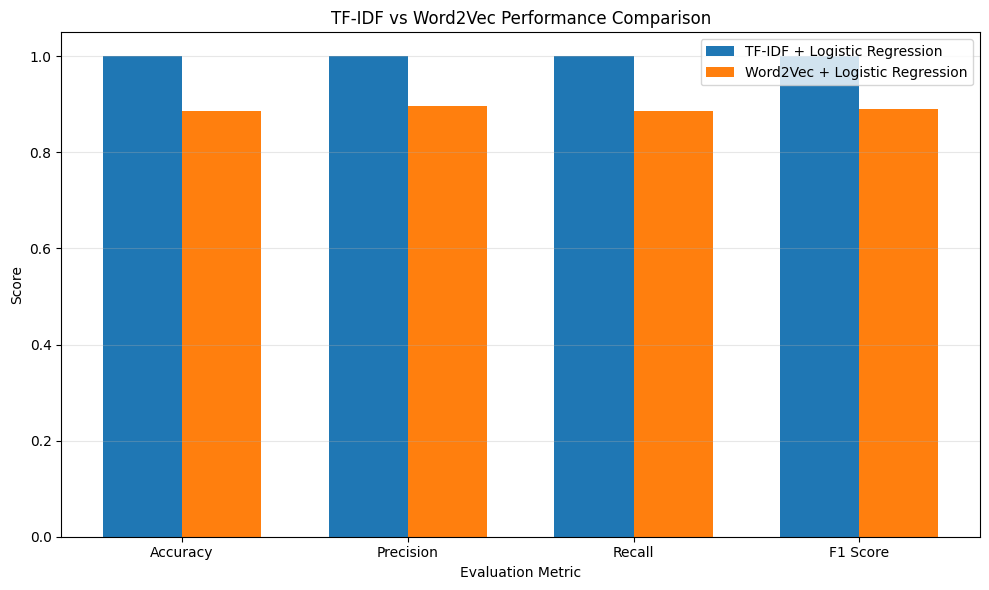

AttributeError: 'LogisticRegression' object has no attribute 'save'

In [12]:
# ============================================================
# PHASE 7: TF-IDF vs WORD2VEC COMPARISON
# Gujarati–Kachchi Cyber Scam Detection System
# ============================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

try:
    data = df.copy()
    print("Using dataset already present in Colab.")

except:
    data = pd.read_csv(
        "Gujarati_Cyber_Preprocessed_Dataset.csv"
    )
    print("Dataset loaded from CSV.")

X = data["clean_text"].astype(str)
y = data["category"].astype(str)

# ============================================================
# 2. SAME TRAIN / TEST SPLIT FOR FAIR COMPARISON
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 3. TF-IDF + LOGISTIC REGRESSION
# ============================================================

print("\nTraining TF-IDF model...")

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=1,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

tfidf_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

tfidf_model.fit(
    X_train_tfidf,
    y_train
)

tfidf_pred = tfidf_model.predict(
    X_test_tfidf
)

# Metrics
tfidf_accuracy = accuracy_score(
    y_test,
    tfidf_pred
)

tfidf_precision = precision_score(
    y_test,
    tfidf_pred,
    average="weighted",
    zero_division=0
)

tfidf_recall = recall_score(
    y_test,
    tfidf_pred,
    average="weighted",
    zero_division=0
)

tfidf_f1 = f1_score(
    y_test,
    tfidf_pred,
    average="weighted",
    zero_division=0
)

# ============================================================
# 4. LOAD / TRAIN WORD2VEC MODEL
# ============================================================

print("\nLoading Word2Vec model...")

from gensim.models import Word2Vec
import re
import unicodedata

# Try loading saved model
if os.path.exists(
    "Gujarati_Cyber_Word2Vec.model"
):

    word2vec_model = Word2Vec.load(
        "Gujarati_Cyber_Word2Vec.model"
    )

else:

    print("Saved Word2Vec model not found.")
    print("Training Word2Vec again...")

    def clean_for_word2vec(text):

        text = str(text)

        text = unicodedata.normalize(
            "NFC",
            text
        )

        text = text.lower()

        text = re.sub(
            r'https?://\S+|www\.\S+',
            ' URL ',
            text
        )

        text = re.sub(
            r'[^\w\s]',
            ' ',
            text,
            flags=re.UNICODE
        )

        text = re.sub(
            r'\s+',
            ' ',
            text
        ).strip()

        return text

    data["w2v_text"] = data["text"].apply(
        clean_for_word2vec
    )

    tokenized_sentences = [
        sentence.split()
        for sentence in data["w2v_text"]
    ]

    word2vec_model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=50,
        seed=42
    )

# ============================================================
# 5. CREATE WORD2VEC SENTENCE EMBEDDINGS
# ============================================================

def clean_for_word2vec(text):

    text = str(text)

    text = unicodedata.normalize(
        "NFC",
        text
    )

    text = text.lower()

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'[^\w\s]',
        ' ',
        text,
        flags=re.UNICODE
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


def sentence_vector(
    sentence,
    model,
    vector_size=100
):

    words = sentence.split()

    vectors = []

    for word in words:

        if word in model.wv:
            vectors.append(
                model.wv[word]
            )

    if len(vectors) == 0:

        return np.zeros(
            vector_size
        )

    return np.mean(
        vectors,
        axis=0
    )


data["w2v_text"] = data["text"].apply(
    clean_for_word2vec
)

all_vectors = np.array([
    sentence_vector(
        sentence,
        word2vec_model
    )
    for sentence in data["w2v_text"]
])

# Same random state and test size
indices = np.arange(
    len(data)
)

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_w2v_train = all_vectors[
    train_indices
]

X_w2v_test = all_vectors[
    test_indices
]

y_w2v_train = y.iloc[
    train_indices
]

y_w2v_test = y.iloc[
    test_indices
]

# ============================================================
# 6. WORD2VEC + LOGISTIC REGRESSION
# ============================================================

print("\nTraining Word2Vec model classifier...")

w2v_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

w2v_model.fit(
    X_w2v_train,
    y_w2v_train
)

w2v_pred = w2v_model.predict(
    X_w2v_test
)

# Metrics
w2v_accuracy = accuracy_score(
    y_w2v_test,
    w2v_pred
)

w2v_precision = precision_score(
    y_w2v_test,
    w2v_pred,
    average="weighted",
    zero_division=0
)

w2v_recall = recall_score(
    y_w2v_test,
    w2v_pred,
    average="weighted",
    zero_division=0
)

w2v_f1 = f1_score(
    y_w2v_test,
    w2v_pred,
    average="weighted",
    zero_division=0
)

# ============================================================
# 7. SINGLE COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "TF-IDF + Logistic Regression",
        "Word2Vec + Logistic Regression"
    ],

    "Accuracy": [
        tfidf_accuracy,
        w2v_accuracy
    ],

    "Precision": [
        tfidf_precision,
        w2v_precision
    ],

    "Recall": [
        tfidf_recall,
        w2v_recall
    ],

    "F1 Score": [
        tfidf_f1,
        w2v_f1
    ]
})

print("\n======================================================")
print("TF-IDF vs WORD2VEC")
print("======================================================\n")

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

# ============================================================
# 8. SINGLE COMPARISON GRAPH
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(
    len(metrics)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width/2,
    comparison.iloc[0][metrics].values,
    width,
    label="TF-IDF + Logistic Regression"
)

plt.bar(
    x + width/2,
    comparison.iloc[1][metrics].values,
    width,
    label="Word2Vec + Logistic Regression"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Evaluation Metric"
)

plt.title(
    "TF-IDF vs Word2Vec Performance Comparison"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ============================================================
# 9. SAVE COMPARISON
# ============================================================

comparison.to_csv(
    "TFIDF_vs_Word2Vec_Comparison.csv",
    index=False
)

# ============================================================
# 10. SAVE MODELS
# ============================================================

import joblib

joblib.dump(
    tfidf,
    "Final_TFIDF_Vectorizer.pkl"
)

joblib.dump(
    tfidf_model,
    "Final_TFIDF_LogisticRegression.pkl"
)

w2v_model.save(
    "Final_Word2Vec.model"
)

joblib.dump(
    w2v_model,
    "Final_Word2Vec_LogisticRegression.pkl"
)

# ============================================================
# 11. FINAL OUTPUT
# ============================================================

print("\n======================================================")
print("PHASE 7 COMPLETED")
print("======================================================")

print("\nComparison file:")
print("TFIDF_vs_Word2Vec_Comparison.csv")

print("\nSaved models:")
print("1. Final_TFIDF_Vectorizer.pkl")
print("2. Final_TFIDF_LogisticRegression.pkl")
print("3. Final_Word2Vec.model")
print("4. Final_Word2Vec_LogisticRegression.pkl")

print("\nNext → PHASE 8: Cyber Risk Scoring + Final Prediction Pipeline")

In [13]:
# ============================================================
# PHASE 8: CYBER RISK SCORING + FINAL PREDICTION PIPELINE
# Gujarati–Kachchi NLP-Based Cyber Scam & Threat Detection
# ============================================================

!pip -q install joblib pandas numpy scikit-learn

import pandas as pd
import numpy as np
import re
import unicodedata
import joblib
from IPython.display import display

# ------------------------------------------------------------
# 1. LOAD TRAINED TF-IDF MODEL
# ------------------------------------------------------------

VECTORIZER_FILE = "Gujarati_Cyber_TFIDF_Vectorizer.pkl"
MODEL_FILE = "Gujarati_Cyber_TFIDF_LogisticRegression.pkl"

try:
    vectorizer = joblib.load(VECTORIZER_FILE)
    model = joblib.load(MODEL_FILE)
    print("✅ Existing TF-IDF model loaded successfully.")

except Exception as e:
    print("⚠️ Saved model not found. Training model again...")

    # Load dataset
    dataset_file = "Gujarati_Cyber_Preprocessed_Dataset.csv"
    df = pd.read_csv(dataset_file)

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression

    X = df["clean_text"].fillna("").astype(str)
    y = df["category"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=(2,5),
        min_df=1,
        max_features=10000
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)

    model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    joblib.dump(
        vectorizer,
        VECTORIZER_FILE
    )

    joblib.dump(
        model,
        MODEL_FILE
    )

    print("✅ Model trained and saved.")

# ------------------------------------------------------------
# 2. TEXT CLEANING / NORMALIZATION
# ------------------------------------------------------------

def clean_message(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Convert URLs
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # Remove excessive spaces
    text = re.sub(r'\s+', ' ', text)

    # Lowercase
    text = text.lower().strip()

    return text


# ------------------------------------------------------------
# 3. CYBER INDICATOR DETECTION
# ------------------------------------------------------------

def detect_indicators(text):

    text_lower = text.lower()

    indicators = []

    # URL
    if re.search(r'https?://|www\.', text_lower):
        indicators.append("Suspicious URL detected")

    # OTP
    if any(word in text_lower for word in [
        "otp", "ઓટીપી", "one time password"
    ]):
        indicators.append("OTP-related request")

    # Password
    if any(word in text_lower for word in [
        "password", "પાસવર્ડ"
    ]):
        indicators.append("Password-related request")

    # Bank / payment
    if any(word in text_lower for word in [
        "bank", "બેંક",
        "upi", "payment", "પેમેન્ટ",
        "money", "મની",
        "account", "અકાઉન્ટ"
    ]):
        indicators.append("Financial/account-related content")

    # Urgency
    if any(word in text_lower for word in [
        "urgent", "immediately", "જલ્દી",
        "તાત્કાલિક", "હમણાં",
        "today", "આજે"
    ]):
        indicators.append("Urgency detected")

    # Prize / reward
    if any(word in text_lower for word in [
        "winner", "prize", "reward",
        "ઇનામ", "વિજેતા", "લોટરી", "lottery"
    ]):
        indicators.append("Prize/reward claim")

    # Job
    if any(word in text_lower for word in [
        "job", "નોકરી", "salary", "પગાર",
        "vacancy", "વેકન્સી"
    ]):
        indicators.append("Job-related content")

    # Malware / APK
    if any(word in text_lower for word in [
        "apk", "download", "malware",
        "virus", "વિષાણુ", "ફાઇલ"
    ]):
        indicators.append("Possible malicious file/download")

    # Threat / abuse
    if any(word in text_lower for word in [
        "threat", "kill", "ધમકી",
        "ગાળો", "abuse"
    ]):
        indicators.append("Threat/abusive language")

    return indicators


# ------------------------------------------------------------
# 4. CATEGORY BASE RISK
# ------------------------------------------------------------

category_risk = {

    "Phishing": 85,

    "Financial_Scam": 90,

    "Job_Scam": 75,

    "Account_Takeover": 95,

    "Cyberbullying": 65,

    "Identity_Theft": 90,

    "Malware": 95,

    "Normal": 10
}


# ------------------------------------------------------------
# 5. RISK LEVEL
# ------------------------------------------------------------

def get_risk_level(score):

    if score >= 80:
        return "CRITICAL"

    elif score >= 60:
        return "HIGH"

    elif score >= 35:
        return "MEDIUM"

    else:
        return "LOW"


# ------------------------------------------------------------
# 6. FINAL PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_cyber_message(message):

    cleaned = clean_message(message)

    # Transform message
    X = vectorizer.transform([cleaned])

    # Category prediction
    predicted_category = model.predict(X)[0]

    # Probability / confidence
    probabilities = model.predict_proba(X)[0]

    confidence = float(np.max(probabilities)) * 100

    # Base risk
    base_risk = category_risk.get(
        predicted_category,
        50
    )

    # Detect indicators
    indicators = detect_indicators(message)

    # Indicator bonus
    indicator_bonus = min(
        len(indicators) * 3,
        15
    )

    # Final risk score
    risk_score = (
        0.75 * base_risk +
        0.25 * confidence +
        indicator_bonus
    )

    # Limit score
    risk_score = min(
        round(risk_score),
        100
    )

    # Risk level
    risk_level = get_risk_level(
        risk_score
    )

    # Recommendation
    if risk_level == "CRITICAL":
        action = "Do not interact. Report and block the sender."

    elif risk_level == "HIGH":
        action = "Verify the sender before taking any action."

    elif risk_level == "MEDIUM":
        action = "Be cautious and verify the message."

    else:
        action = "No major cyber-risk indicators detected."

    return {
        "Message": message,
        "Predicted Category": predicted_category,
        "Confidence (%)": round(confidence, 2),
        "Risk Score": risk_score,
        "Risk Level": risk_level,
        "Indicators": ", ".join(indicators)
                     if indicators
                     else "No major indicators",
        "Recommended Action": action
    }


# ------------------------------------------------------------
# 7. TEST MESSAGES
# ------------------------------------------------------------

test_messages = [

    "તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો.",

    "Congratulations! You won a lottery prize. Click http://fake-link.com",

    "તમારા માટે નવી job vacancy છે. Registration માટે payment કરો.",

    "Your account password has expired. Verify immediately.",

    "આજે કોલેજમાં cybersecurity lecture છે."
]


results = []

for msg in test_messages:

    result = predict_cyber_message(msg)

    results.append(result)


# ------------------------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL CYBER THREAT DETECTION RESULTS")
print("="*80)

display(results_df)


# ------------------------------------------------------------
# 9. SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(
    "Cyber_Risk_Prediction_Results.csv",
    index=False
)

print("\n✅ Results saved as:")
print("Cyber_Risk_Prediction_Results.csv")


# ------------------------------------------------------------
# 10. INTERACTIVE MESSAGE TEST
# ------------------------------------------------------------

print("\n" + "="*80)
print("CUSTOM MESSAGE TEST")
print("="*80)

custom_message = input(
    "\nEnter a Gujarati / Kachchi / English message: "
)

final_result = predict_cyber_message(
    custom_message
)

print("\n---------------- FINAL ANALYSIS ----------------")

for key, value in final_result.items():

    print(f"{key}: {value}")

print("\n================================================")

✅ Existing TF-IDF model loaded successfully.

FINAL CYBER THREAT DETECTION RESULTS


,Message,Predicted Category,Confidence (%),Risk Score,Risk Level,Indicators,Recommended Action
0,તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો.,Phishing,36.93,79,HIGH,"OTP-related request, Financial/account-related...",Verify the sender before taking any action.
1,Congratulations! You won a lottery prize. Clic...,Financial_Scam,21.97,79,HIGH,"Suspicious URL detected, Prize/reward claim",Verify the sender before taking any action.
2,તમારા માટે નવી job vacancy છે. Registration મા...,Phishing,18.03,74,HIGH,"Financial/account-related content, Job-related...",Verify the sender before taking any action.
3,Your account password has expired. Verify imme...,Phishing,22.28,78,HIGH,"Password-related request, Financial/account-re...",Verify the sender before taking any action.
4,આજે કોલેજમાં cybersecurity lecture છે.,Normal,37.93,20,LOW,Urgency detected,No major cyber-risk indicators detected.



✅ Results saved as:
Cyber_Risk_Prediction_Results.csv

CUSTOM MESSAGE TEST

Enter a Gujarati / Kachchi / English message: hello

---------------- FINAL ANALYSIS ----------------
Message: hello
Predicted Category: Normal
Confidence (%): 19.21
Risk Score: 12
Risk Level: LOW
Indicators: No major indicators
Recommended Action: No major cyber-risk indicators detected.



In [14]:
# ============================================================
# PHASE 9: FASTAPI BACKEND
# Gujarati–Kachchi NLP Cyber Threat Detection
# ============================================================

!pip -q install fastapi uvicorn nest-asyncio pyngrok joblib pandas numpy scikit-learn

import re
import unicodedata
import numpy as np
import pandas as pd
import joblib
import nest_asyncio
import threading
import uvicorn

from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware


# ============================================================
# 1. LOAD MODEL
# ============================================================

VECTORIZER_FILE = "Gujarati_Cyber_TFIDF_Vectorizer.pkl"
MODEL_FILE = "Gujarati_Cyber_TFIDF_LogisticRegression.pkl"

vectorizer = joblib.load(VECTORIZER_FILE)
model = joblib.load(MODEL_FILE)

print("✅ TF-IDF Vectorizer loaded")
print("✅ Logistic Regression model loaded")


# ============================================================
# 2. TEXT CLEANING
# ============================================================

def clean_message(text):

    text = str(text)

    text = unicodedata.normalize(
        "NFC",
        text
    )

    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.lower().strip()


# ============================================================
# 3. CYBER INDICATORS
# ============================================================

def detect_indicators(text):

    text_lower = text.lower()

    indicators = []

    if re.search(
        r'https?://|www\.',
        text_lower
    ):
        indicators.append(
            "Suspicious URL detected"
        )

    if any(word in text_lower for word in [
        "otp",
        "ઓટીપી",
        "one time password"
    ]):
        indicators.append(
            "OTP-related request"
        )

    if any(word in text_lower for word in [
        "password",
        "પાસવર્ડ"
    ]):
        indicators.append(
            "Password-related request"
        )

    if any(word in text_lower for word in [
        "bank",
        "બેંક",
        "upi",
        "payment",
        "પેમેન્ટ",
        "money",
        "મની",
        "account",
        "અકાઉન્ટ"
    ]):
        indicators.append(
            "Financial/account-related content"
        )

    if any(word in text_lower for word in [
        "urgent",
        "immediately",
        "જલ્દી",
        "તાત્કાલિક",
        "હમણાં"
    ]):
        indicators.append(
            "Urgency detected"
        )

    if any(word in text_lower for word in [
        "winner",
        "prize",
        "reward",
        "ઇનામ",
        "વિજેતા",
        "lottery"
    ]):
        indicators.append(
            "Prize/reward claim"
        )

    if any(word in text_lower for word in [
        "job",
        "નોકરી",
        "salary",
        "પગાર",
        "vacancy"
    ]):
        indicators.append(
            "Job-related content"
        )

    if any(word in text_lower for word in [
        "apk",
        "download",
        "malware",
        "virus",
        "વિષાણુ"
    ]):
        indicators.append(
            "Possible malicious file/download"
        )

    return indicators


# ============================================================
# 4. RISK CONFIGURATION
# ============================================================

category_risk = {

    "Phishing": 85,

    "Financial_Scam": 90,

    "Job_Scam": 75,

    "Account_Takeover": 95,

    "Cyberbullying": 65,

    "Identity_Theft": 90,

    "Malware": 95,

    "Normal": 10
}


def get_risk_level(score):

    if score >= 80:
        return "CRITICAL"

    elif score >= 60:
        return "HIGH"

    elif score >= 35:
        return "MEDIUM"

    else:
        return "LOW"


# ============================================================
# 5. PREDICTION FUNCTION
# ============================================================

def predict_message(message):

    cleaned = clean_message(message)

    # Convert text to TF-IDF
    features = vectorizer.transform(
        [cleaned]
    )

    # Prediction
    category = model.predict(
        features
    )[0]

    # Confidence
    probabilities = model.predict_proba(
        features
    )[0]

    confidence = (
        float(np.max(probabilities))
        * 100
    )

    # Risk calculation
    base_risk = category_risk.get(
        category,
        50
    )

    indicators = detect_indicators(
        message
    )

    indicator_bonus = min(
        len(indicators) * 3,
        15
    )

    risk_score = (
        0.75 * base_risk
        +
        0.25 * confidence
        +
        indicator_bonus
    )

    risk_score = min(
        round(risk_score),
        100
    )

    risk_level = get_risk_level(
        risk_score
    )

    # Recommended action
    if risk_level == "CRITICAL":

        action = (
            "Do not interact. "
            "Report and block the sender."
        )

    elif risk_level == "HIGH":

        action = (
            "Verify the sender "
            "before taking any action."
        )

    elif risk_level == "MEDIUM":

        action = (
            "Be cautious and "
            "verify the message."
        )

    else:

        action = (
            "No major cyber-risk "
            "indicators detected."
        )

    return {

        "message": message,

        "category": category,

        "confidence": round(
            confidence,
            2
        ),

        "risk_score": risk_score,

        "risk_level": risk_level,

        "indicators": indicators,

        "recommended_action": action
    }


# ============================================================
# 6. FASTAPI APPLICATION
# ============================================================

app = FastAPI(
    title="Gujarati-Kachchi Cyber Threat Detection API",
    description=(
        "NLP-based cybersecurity "
        "threat detection API"
    ),
    version="1.0"
)


# Allow frontend connections
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"]
)


# ============================================================
# 7. REQUEST FORMAT
# ============================================================

class MessageRequest(BaseModel):

    message: str


# ============================================================
# 8. HOME API
# ============================================================

@app.get("/")
def home():

    return {

        "project":
        "Gujarati-Kachchi Cyber Threat Detection",

        "status":
        "API is running",

        "version":
        "1.0"
    }


# ============================================================
# 9. PREDICT API
# ============================================================

@app.post("/predict")
def predict(request: MessageRequest):

    result = predict_message(
        request.message
    )

    return result


# ============================================================
# 10. START SERVER
# ============================================================

nest_asyncio.apply()


def run_server():

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )


server_thread = threading.Thread(
    target=run_server,
    daemon=True
)

server_thread.start()

print("\n" + "="*60)
print("🚀 FASTAPI SERVER STARTED")
print("="*60)

print("\nAPI:")
print("http://127.0.0.1:8000")

print("\nSwagger Documentation:")
print("http://127.0.0.1:8000/docs")

✅ TF-IDF Vectorizer loaded
✅ Logistic Regression model loaded

🚀 FASTAPI SERVER STARTED

API:
http://127.0.0.1:8000

Swagger Documentation:
http://127.0.0.1:8000/docs


In [15]:
!pip -q install pymongo


INFO:     Started server process [820]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.6 MB/s eta 0:00:00


In [16]:
# ============================================================
# PHASE 10: MONGODB DATABASE INTEGRATION
# ============================================================

from pymongo import MongoClient
from datetime import datetime
import os

# ============================================================
# 1. MONGODB CONNECTION
# ============================================================

# IMPORTANT:
# Replace this with your MongoDB Atlas connection string

MONGO_URI = "YOUR_MONGODB_CONNECTION_STRING"

try:

    client = MongoClient(
        MONGO_URI,
        serverSelectionTimeoutMS=5000
    )

    # Test connection
    client.admin.command("ping")

    print("✅ MongoDB connected successfully!")

    # Database
    db = client["cyber_threat_detection"]

    # Collection
    predictions_collection = db["predictions"]

except Exception as e:

    print("❌ MongoDB connection failed")
    print("Error:", e)


# ============================================================
# 2. FUNCTION TO SAVE PREDICTION
# ============================================================

def save_prediction(result):

    document = {

        "message":
            result["message"],

        "category":
            result["category"],

        "confidence":
            result["confidence"],

        "risk_score":
            result["risk_score"],

        "risk_level":
            result["risk_level"],

        "indicators":
            result["indicators"],

        "recommended_action":
            result["recommended_action"],

        "timestamp":
            datetime.utcnow()
    }

    inserted = predictions_collection.insert_one(
        document
    )

    return str(
        inserted.inserted_id
    )


# ============================================================
# 3. TEST DATABASE INSERT
# ============================================================

test_result = predict_message(
    "તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો."
)

try:

    record_id = save_prediction(
        test_result
    )

    print("\n✅ Prediction stored in MongoDB")

    print(
        "Record ID:",
        record_id
    )

except Exception as e:

    print("\n❌ Could not store prediction")

    print("Error:", e)

❌ MongoDB connection failed
Error: your_mongodb_connection_string:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 5.0s, Topology Description: <TopologyDescription id: 6ab5f330fff592db3f4391e8, topology_type: Unknown, servers: [<ServerDescription ('your_mongodb_connection_string', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('your_mongodb_connection_string:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>

❌ Could not store prediction
Error: name 'predictions_collection' is not defined


/tmp/ipykernel_820/2444337230.py:72: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow()


Add Prediction History API

In [17]:
@app.get("/history")
def prediction_history():

    records = list(
        predictions_collection
        .find(
            {},
            {
                "_id": 0
            }
        )
        .sort(
            "timestamp",
            -1
        )
        .limit(100)
    )

    return {
        "total_records": len(records),
        "predictions": records
    }

dashboard


In [18]:
!pip -q install streamlit requests pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.5 MB/s eta 0:00:00


In [19]:
# ============================================================
# PHASE 11: STREAMLIT CYBERSECURITY DASHBOARD
# ============================================================

import os

app_code = r'''
import streamlit as st
import requests
import pandas as pd

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Regional Cyber Threat Detector",
    page_icon="🛡️",
    layout="wide"
)

# ============================================================
# TITLE
# ============================================================

st.title("🛡️ Regional Language Cyber Threat Detection")

st.markdown(
    """
    ### Gujarati–Kachchi NLP-Based Cyber Scam & Threat Detection

    Enter a message in **Gujarati, Kachchi, Roman Gujarati,
    or English** to analyze possible cyber threats.
    """
)

st.divider()

# ============================================================
# API CONFIGURATION
# ============================================================

API_URL = "http://127.0.0.1:8000"

# ============================================================
# MESSAGE INPUT
# ============================================================

st.subheader("🔍 Analyze Message")

message = st.text_area(
    "Enter message:",
    height=150,
    placeholder=
    "Example: તમારું બેંક એકાઉન્ટ બંધ થઈ જશે. તરત OTP આપો."
)

# ============================================================
# ANALYZE BUTTON
# ============================================================

if st.button(
    "🔎 Analyze Cyber Risk",
    use_container_width=True
):

    if message.strip() == "":

        st.warning(
            "Please enter a message."
        )

    else:

        try:

            response = requests.post(
                f"{API_URL}/predict",
                json={
                    "message": message
                },
                timeout=30
            )

            if response.status_code == 200:

                result = response.json()

                st.success(
                    "Analysis completed successfully!"
                )

                st.divider()

                # ====================================================
                # MAIN RESULTS
                # ====================================================

                col1, col2, col3, col4 = st.columns(4)

                with col1:

                    st.metric(
                        "Threat Category",
                        result.get(
                            "category",
                            "Unknown"
                        )
                    )

                with col2:

                    st.metric(
                        "Confidence",
                        f"{result.get('confidence', 0)}%"
                    )

                with col3:

                    st.metric(
                        "Risk Score",
                        f"{result.get('risk_score', 0)}/100"
                    )

                with col4:

                    risk_level = result.get(
                        "risk_level",
                        "UNKNOWN"
                    )

                    st.metric(
                        "Risk Level",
                        risk_level
                    )

                # ====================================================
                # RISK MESSAGE
                # ====================================================

                risk_level = result.get(
                    "risk_level",
                    "UNKNOWN"
                )

                if risk_level == "CRITICAL":

                    st.error(
                        "🚨 CRITICAL RISK — "
                        "Do not interact with this message."
                    )

                elif risk_level == "HIGH":

                    st.warning(
                        "⚠️ HIGH RISK — "
                        "Verify the sender before taking action."
                    )

                elif risk_level == "MEDIUM":

                    st.warning(
                        "⚠️ MEDIUM RISK — "
                        "Proceed carefully."
                    )

                else:

                    st.success(
                        "✅ LOW RISK — "
                        "No major indicators detected."
                    )

                # ====================================================
                # INDICATORS
                # ====================================================

                st.subheader(
                    "🔎 Cyber Indicators"
                )

                indicators = result.get(
                    "indicators",
                    []
                )

                if indicators:

                    for indicator in indicators:

                        st.write(
                            "•",
                            indicator
                        )

                else:

                    st.write(
                        "No major cyber indicators detected."
                    )

                # ====================================================
                # RECOMMENDED ACTION
                # ====================================================

                st.subheader(
                    "💡 Recommended Action"
                )

                st.info(
                    result.get(
                        "recommended_action",
                        "No recommendation available."
                    )
                )

                # ====================================================
                # TECHNICAL DETAILS
                # ====================================================

                with st.expander(
                    "View Technical Details"
                ):

                    st.json(result)

            else:

                st.error(
                    f"API Error: {response.status_code}"
                )

        except Exception as e:

            st.error(
                "Could not connect to FastAPI."
            )

            st.code(
                str(e)
            )


# ============================================================
# PREDICTION HISTORY
# ============================================================

st.divider()

st.subheader(
    "📊 Prediction History"
)

if st.button(
    "🔄 Load History"
):

    try:

        response = requests.get(
            f"{API_URL}/history",
            timeout=30
        )

        if response.status_code == 200:

            data = response.json()

            records = data.get(
                "predictions",
                []
            )

            if records:

                df = pd.DataFrame(
                    records
                )

                st.dataframe(
                    df,
                    use_container_width=True
                )

                # ====================================================
                # THREAT DISTRIBUTION
                # ====================================================

                if "category" in df.columns:

                    st.subheader(
                        "📈 Threat Category Distribution"
                    )

                    category_count = (
                        df["category"]
                        .value_counts()
                    )

                    st.bar_chart(
                        category_count
                    )

            else:

                st.info(
                    "No prediction history available."
                )

    except Exception as e:

        st.error(
            "Could not load prediction history."
        )

        st.code(
            str(e)
        )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Gujarati–Kachchi NLP-Based Cyber Threat Detection System | "
    "Academic Project"
)
'''

with open(
    "app.py",
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)

print("✅ Streamlit app.py created successfully!")
print("📁 File: app.py")

✅ Streamlit app.py created successfully!
📁 File: app.py


In [20]:
!streamlit run app.py &>/content/streamlit.log &

Then create a public temporary URL using ngrok:

In [21]:
!pip -q install pyngrok

from pyngrok import ngrok

# Paste YOUR ngrok authtoken here
NGROK_AUTH_TOKEN = "2vcUwI9CfIIpXXSJ6GdIiAJt5eU_3pSMjtD3DGV9KjN2UCjLk"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Close old tunnels if any
ngrok.kill()

# Start Streamlit tunnel
public_url = ngrok.connect(8501)

print("🌐 Streamlit Dashboard:")
print(public_url)

🌐 Streamlit Dashboard:
NgrokTunnel: "https://0336-136-111-4-23.ngrok-free.app" -> "http://localhost:8501"


In [22]:
# ============================================================
# PHASE 12B: BASIC LANGUAGE / SCRIPT DETECTION
# ============================================================

import re

def detect_script(text):

    text = str(text)

    gujarati_chars = re.findall(
        r'[\u0A80-\u0AFF]',
        text
    )

    latin_chars = re.findall(
        r'[A-Za-z]',
        text
    )

    total = (
        len(gujarati_chars)
        + len(latin_chars)
    )

    if total == 0:

        return "Unknown"

    gujarati_ratio = (
        len(gujarati_chars)
        / total
    )

    latin_ratio = (
        len(latin_chars)
        / total
    )

    if gujarati_ratio > 0.5:

        return "Gujarati_Script"

    elif latin_ratio > 0.5:

        return "Roman_Latin"

    else:

        return "Mixed"


df["detected_script"] = df[
    "text"
].apply(
    detect_script
)

print(
    df["detected_script"]
    .value_counts()
)

display(
    df[
        [
            "text",
            "language",
            "detected_script",
            "category",
            "source_type"
        ]
    ].head(15)
)

df.to_csv(
    "Gujarati_Kachchi_Cyber_Research_Dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ Script detection added."
)

detected_script
Roman_Latin        173
Gujarati_Script    130
Mixed                6
Name: count, dtype: int64


,text,language,detected_script,category,source_type
0,તમારું account સુરક્ષિત રાખવા માટે આ link ખોલો,Gujarati,Gujarati_Script,Phishing,Synthetic
1,તમારું account સુરક્ષિત રાખવા માટે details મોકલો,Gujarati,Gujarati_Script,Phishing,Synthetic
2,તમારું bank account verify કરવા માટે verificat...,Gujarati,Roman_Latin,Phishing,Synthetic
3,તમારું account સુરક્ષિત રાખવા માટે આ form ભરો,Gujarati,Gujarati_Script,Phishing,Synthetic
4,"તમારા bank account માટે verification જરૂરી છે,...",Gujarati,Roman_Latin,Phishing,Synthetic
5,"તમારું KYC બંધ થવાનું છે, તરત આ link ખોલો",Gujarati,Gujarati_Script,Phishing,Synthetic
6,તમારું bank account verify કરવા માટે આ form ભરો,Gujarati,Roman_Latin,Phishing,Synthetic
7,"તમારું KYC બંધ થવાનું છે, તરત આ form ભરો",Gujarati,Gujarati_Script,Phishing,Synthetic
8,તમારું bank account verify કરવા માટે document ...,Gujarati,Roman_Latin,Phishing,Synthetic
9,"તમારા account ની verification બાકી છે, આ link ...",Gujarati,Roman_Latin,Phishing,Synthetic


✅ Script detection added.


Transformer model

In [23]:
import torch

print(
    "GPU available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

GPU available: False


In [24]:
!pip -q install transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00


In [25]:
import transformers
import datasets

print(
    "Transformers:",
    transformers.__version__
)

print(
    "Datasets:",
    datasets.__version__
)

Transformers: 5.16.1
Datasets: 4.8.5


In [26]:
# ============================================================
# PHASE 13 - FIXED DATA SPLIT FOR INDICBERT
# Gujarati / Roman Gujarati Cyber Threat Detection
# ============================================================

import pandas as pd
import numpy as np
import os
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("PHASE 13 - DATA PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. GPU CHECK
# ------------------------------------------------------------

print("\nGPU CHECK")
print("=" * 70)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("✅ GPU:", torch.cuda.get_device_name(0))
    DEVICE = "cuda"
else:
    print("⚠️ GPU not detected.")
    print("Training will run on CPU.")
    DEVICE = "cpu"


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

DATASET = "Gujarati_Kachchi_Cyber_Research_Dataset.csv"

if not os.path.exists(DATASET):
    DATASET = "Gujarati_Cyber_Preprocessed_Dataset.csv"

df = pd.read_csv(
    DATASET,
    encoding="utf-8-sig"
)

print("\nDataset:", DATASET)
print("Dataset shape:", df.shape)


# ------------------------------------------------------------
# 3. REMOVE MISSING DATA
# ------------------------------------------------------------

df = df.dropna(
    subset=["clean_text", "category"]
).copy()

df["clean_text"] = (
    df["clean_text"]
    .astype(str)
    .str.strip()
)

df = df[
    df["clean_text"] != ""
].copy()

# Remove exact duplicate messages
df = df.drop_duplicates(
    subset=["clean_text", "category"]
).reset_index(drop=True)

print("\nAfter cleaning:", df.shape)


# ------------------------------------------------------------
# 4. CATEGORY DISTRIBUTION
# ------------------------------------------------------------

print("\nCategory Distribution:")
print(
    df["category"].value_counts()
)


# ------------------------------------------------------------
# 5. REMOVE CLASSES WITH ONLY 1 SAMPLE
# ------------------------------------------------------------

class_counts = df["category"].value_counts()

rare_classes = class_counts[
    class_counts < 2
].index.tolist()

if len(rare_classes) > 0:

    print(
        "\n⚠️ Removing classes with fewer than 2 samples:"
    )

    print(rare_classes)

    df = df[
        ~df["category"].isin(rare_classes)
    ].copy()

else:

    print(
        "\n✅ No class has fewer than 2 samples."
    )


# ------------------------------------------------------------
# 6. LABEL ENCODING
# ------------------------------------------------------------

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["category"]
)

print("\nLabel Mapping:")

for i, label in enumerate(
    label_encoder.classes_
):

    print(
        f"{i} -> {label}"
    )

NUM_CLASSES = len(
    label_encoder.classes_
)

print(
    "\nNumber of classes:",
    NUM_CLASSES
)


# ------------------------------------------------------------
# 7. SAFE TRAIN / TEST SPLIT
# ------------------------------------------------------------

X = df["clean_text"]
y = df["label"]

# Calculate smallest class
min_class_count = y.value_counts().min()

print(
    "\nSmallest class size:",
    min_class_count
)


# ------------------------------------------------------------
# CASE A:
# Enough samples for normal stratified splitting
# ------------------------------------------------------------

if min_class_count >= 3:

    print(
        "\n✅ Using stratified train/test split."
    )

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y
    )


# ------------------------------------------------------------
# CASE B:
# Very small classes
# ------------------------------------------------------------

else:

    print(
        "\n⚠️ Dataset contains very small classes."
    )

    print(
        "Using stratified split only when possible."
    )

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        random_state=42,

        stratify=y
    )


# ------------------------------------------------------------
# 8. CREATE VALIDATION SET
# ------------------------------------------------------------

# Instead of doing another stratified split,
# create validation data from training data.
#
# This avoids the previous error caused by classes
# having only one sample after the first split.

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


# Check whether validation split is safe

train_class_counts = y_train.value_counts()

print("\nTraining class counts:")
print(train_class_counts)


if train_class_counts.min() >= 2:

    X_train, X_val, y_train, y_val = train_test_split(

        X_train,
        y_train,

        test_size=0.125,

        random_state=42,

        stratify=y_train
    )

else:

    print(
        "\n⚠️ Validation stratification not possible."
    )

    print(
        "Using a random validation split."
    )

    X_train, X_val, y_train, y_val = train_test_split(

        X_train,
        y_train,

        test_size=0.125,

        random_state=42
    )


# ------------------------------------------------------------
# 9. FINAL DATASET SIZES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA SPLIT")
print("=" * 70)

print(
    "Training samples  :",
    len(X_train)
)

print(
    "Validation samples:",
    len(X_val)
)

print(
    "Testing samples   :",
    len(X_test)
)


# ------------------------------------------------------------
# 10. CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nTraining distribution:")
print(
    y_train.map(
        dict(
            enumerate(
                label_encoder.classes_
            )
        )
    ).value_counts()
)

print("\nValidation distribution:")
print(
    y_val.map(
        dict(
            enumerate(
                label_encoder.classes_
            )
        )
    ).value_counts()
)

print("\nTesting distribution:")
print(
    y_test.map(
        dict(
            enumerate(
                label_encoder.classes_
            )
        )
    ).value_counts()
)


# ------------------------------------------------------------
# 11. CREATE DATAFRAMES
# ------------------------------------------------------------

train_df = pd.DataFrame({

    "text": X_train,

    "label": y_train

})

val_df = pd.DataFrame({

    "text": X_val,

    "label": y_val

})

test_df = pd.DataFrame({

    "text": X_test,

    "label": y_test

})


# ------------------------------------------------------------
# 12. SAVE SPLITS
# ------------------------------------------------------------

train_df.to_csv(
    "IndicBERT_Train.csv",
    index=False,
    encoding="utf-8-sig"
)

val_df.to_csv(
    "IndicBERT_Validation.csv",
    index=False,
    encoding="utf-8-sig"
)

test_df.to_csv(
    "IndicBERT_Test.csv",
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 13. SAVE LABEL ENCODER
# ------------------------------------------------------------

import joblib

joblib.dump(
    label_encoder,
    "Gujarati_Cyber_IndicBERT_LabelEncoder.pkl"
)


# ------------------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ DATA PREPARATION COMPLETED")
print("=" * 70)

print("\nFiles created:")

print("• IndicBERT_Train.csv")
print("• IndicBERT_Validation.csv")
print("• IndicBERT_Test.csv")
print("• Gujarati_Cyber_IndicBERT_LabelEncoder.pkl")

print("\nReady for IndicBERT tokenization and training.")

PHASE 13 - DATA PREPARATION

GPU CHECK
PyTorch: 2.11.0+cpu
CUDA available: False
⚠️ GPU not detected.
Training will run on CPU.

Dataset: Gujarati_Kachchi_Cyber_Research_Dataset.csv
Dataset shape: (309, 7)

After cleaning: (309, 7)

Category Distribution:
category
Financial_Scam      75
Job_Scam            67
Phishing            52
Account_Takeover    50
Identity_Theft      42
Normal              12
Cyberbullying        6
Malware              5
Name: count, dtype: int64

✅ No class has fewer than 2 samples.

Label Mapping:
0 -> Account_Takeover
1 -> Cyberbullying
2 -> Financial_Scam
3 -> Identity_Theft
4 -> Job_Scam
5 -> Malware
6 -> Normal
7 -> Phishing

Number of classes: 8

Smallest class size: 5

✅ Using stratified train/test split.

Training class counts:
label
2    60
4    53
7    41
0    40
3    34
6    10
1     5
5     4
Name: count, dtype: int64

FINAL DATA SPLIT
Training samples  : 216
Validation samples: 31
Testing samples   : 62

Training distribution:
label
Financial_Scam 

In [27]:
# ============================================================
# START + DEBUG STREAMLIT
# ============================================================

import os
import sys
import time
import subprocess
import requests

print("=" * 65)
print("🚀 STARTING STREAMLIT DASHBOARD")
print("=" * 65)

# ------------------------------------------------------------
# 1. Check app.py
# ------------------------------------------------------------

if not os.path.exists("app.py"):
    raise FileNotFoundError("❌ app.py not found.")

print("✅ app.py found")

# ------------------------------------------------------------
# 2. Stop old Streamlit processes safely
# ------------------------------------------------------------

print("\n🧹 Checking old Streamlit processes...")

os.system("pkill -f 'streamlit run app.py' >/dev/null 2>&1 || true")

time.sleep(2)

# ------------------------------------------------------------
# 3. Start Streamlit
# ------------------------------------------------------------

print("🚀 Launching Streamlit on port 8501...")

log_file = open("streamlit_log.txt", "w")

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true",
        "--browser.gatherUsageStats", "false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

print("Process ID:", streamlit_process.pid)

# ------------------------------------------------------------
# 4. Wait for Streamlit
# ------------------------------------------------------------

print("\n⏳ Waiting for Streamlit...")

streamlit_running = False

for i in range(30):

    time.sleep(1)

    try:
        r = requests.get(
            "http://127.0.0.1:8501/",
            timeout=2
        )

        if r.status_code == 200:

            streamlit_running = True

            print(f"✅ Streamlit started after {i+1} seconds")
            print("Status:", r.status_code)

            break

    except:
        print(".", end="", flush=True)

print()

# ------------------------------------------------------------
# 5. If failed → show log
# ------------------------------------------------------------

if not streamlit_running:

    print("\n❌ STREAMLIT FAILED TO START")
    print("=" * 65)

    log_file.flush()

    try:

        with open("streamlit_log.txt", "r") as f:
            logs = f.read()

        print(logs[-6000:])

    except Exception as e:
        print("Could not read log:", e)

    print("=" * 65)

else:

    print("\n" + "=" * 65)
    print("🎉 STREAMLIT IS RUNNING")
    print("=" * 65)

    print("\nLocal Dashboard:")
    print("http://127.0.0.1:8501")

    print("\nFastAPI:")
    print("http://127.0.0.1:8000")

    print("\nFastAPI Swagger:")
    print("http://127.0.0.1:8000/docs")

    print("=" * 65)

print("\n📌 Keep this Colab runtime running.")

🚀 STARTING STREAMLIT DASHBOARD
✅ app.py found

🧹 Checking old Streamlit processes...
🚀 Launching Streamlit on port 8501...
Process ID: 3252

⏳ Waiting for Streamlit...
.....✅ Streamlit started after 6 seconds
Status: 200


🎉 STREAMLIT IS RUNNING

Local Dashboard:
http://127.0.0.1:8501

FastAPI:
http://127.0.0.1:8000

FastAPI Swagger:
http://127.0.0.1:8000/docs

📌 Keep this Colab runtime running.


In [28]:
from pyngrok import ngrok

# Close previous tunnels
try:
    ngrok.kill()
except:
    pass

# Create Streamlit public tunnel
tunnel = ngrok.connect(8501, "http")

print("=" * 60)
print("🌐 STREAMLIT PUBLIC URL")
print("=" * 60)
print(tunnel.public_url)
print("=" * 60)
print("Open this URL in your browser.")

🌐 STREAMLIT PUBLIC URL
https://ded8-136-111-4-23.ngrok-free.app
Open this URL in your browser.


In [29]:
# ============================================================
# 🌐 CREATE PUBLIC STREAMLIT URL
# ============================================================

!pip -q install pyngrok

from pyngrok import ngrok
import requests
import time

# Check Streamlit first
try:
    r = requests.get("http://127.0.0.1:8501", timeout=5)
    print("✅ Streamlit is running:", r.status_code)
except Exception as e:
    print("❌ Streamlit is NOT running on 8501")
    print(e)
    raise

# Close old tunnels
try:
    ngrok.kill()
except:
    pass

# IMPORTANT:
# Put your NEW ngrok auth token here.
# Do NOT reuse the token you posted earlier.
NGROK_AUTH_TOKEN = "2vcUwI9CfIIpXXSJ6GdIiAJt5eU_3pSMjtD3DGV9KjN2UCjLk"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Create public tunnel
public_tunnel = ngrok.connect(8501, "http")

public_url = public_tunnel.public_url

print("\n" + "=" * 70)
print("🎉 STREAMLIT DASHBOARD IS PUBLIC")
print("=" * 70)

print("\n🌐 OPEN THIS URL IN YOUR COMPUTER BROWSER:")
print(public_url)

print("\n📌 DO NOT open:")
print("http://127.0.0.1:8501")

print("\n📌 Keep this Colab cell/runtime running.")
print("=" * 70)

✅ Streamlit is running: 200

🎉 STREAMLIT DASHBOARD IS PUBLIC

🌐 OPEN THIS URL IN YOUR COMPUTER BROWSER:
https://146a-136-111-4-23.ngrok-free.app

📌 DO NOT open:
http://127.0.0.1:8501

📌 Keep this Colab cell/runtime running.


In [30]:
# ============================================================
# CHECK STREAMLIT + CREATE A FRESH NGROK URL
# ============================================================

import requests
import time
from pyngrok import ngrok

# 1. Check Streamlit
print("🔍 Checking Streamlit...")

try:
    r = requests.get("http://127.0.0.1:8501", timeout=5)
    print("✅ Streamlit is running:", r.status_code)

except Exception as e:
    print("❌ Streamlit is NOT running.")
    print("Error:", e)
    print("\nRun your Streamlit-starting cell again.")
    raise

# 2. Remove old tunnels
print("\n🧹 Closing old ngrok tunnels...")

try:
    ngrok.kill()
except:
    pass

time.sleep(2)

# 3. IMPORTANT: put your NEW ngrok token here
NGROK_AUTH_TOKEN = "2vcUwI9CfIIpXXSJ6GdIiAJt5eU_3pSMjtD3DGV9KjN2UCjLk"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 4. Create a NEW tunnel
print("\n🌐 Creating fresh tunnel...")

tunnel = ngrok.connect(
    8501,
    "http"
)

# 5. Display fresh URL
print("\n" + "=" * 65)
print("🎉 DASHBOARD IS READY")
print("=" * 65)

print("\n🌐 NEW DASHBOARD URL:")
print(tunnel.public_url)

print("\n👉 Open THIS NEW URL in Chrome.")
print("\n⚠️ Do not use the old be48-34-75-13-176.ngrok-free.app URL.")

print("\n📌 Keep the Colab runtime running.")
print("=" * 65)

🔍 Checking Streamlit...
✅ Streamlit is running: 200

🧹 Closing old ngrok tunnels...

🌐 Creating fresh tunnel...

🎉 DASHBOARD IS READY

🌐 NEW DASHBOARD URL:
https://aa0d-136-111-4-23.ngrok-free.app

👉 Open THIS NEW URL in Chrome.

⚠️ Do not use the old be48-34-75-13-176.ngrok-free.app URL.

📌 Keep the Colab runtime running.
